# NICER DATA Pulsar Frequency Explorer

Jacob Payne
27 Jan 2026

In [2]:
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import sqrt
from nicer_data_prep import read_xamin_table, get_evt_data, write_barycorr_sh, bulk_process

In [3]:
obsid = '1070010127'
evt_data = get_evt_data(obsid)  # requires mpu7 from nicerl2

print(evt_data.colnames)
print(len(evt_data))

['TIME', 'RAWX', 'RAWY', 'PHA', 'PHA_FAST', 'DET_ID', 'DEADTIME', 'EVENT_FLAGS', 'TICK', 'MPU_A_TEMP', 'MPU_UNDER_COUNT', 'PI_FAST', 'PI', 'PI_RATIO', 'BARYTIME', 'BARY_REF_TIME', 'PHASE']
169903


In [ ]:
# fourier transform of the time series to look for periodicities
time_series = evt_data['TIME']
# bin the time series
bin_size = 0.00001  # 10 μs bins
max_time = time_series.max()
min_time = time_series.min()
print(f'Min time: {min_time}, Max time: {max_time}')
#print the duraction rounding to the tenths place
duration = round(max_time - min_time, 1)
print(f'Duration: {duration} s')
ref_time_series = time_series - min_time  # shift to start at 0

Min time: 115173107.00139773, Max time: 115251454.7221225
Duration: 78347.7 s


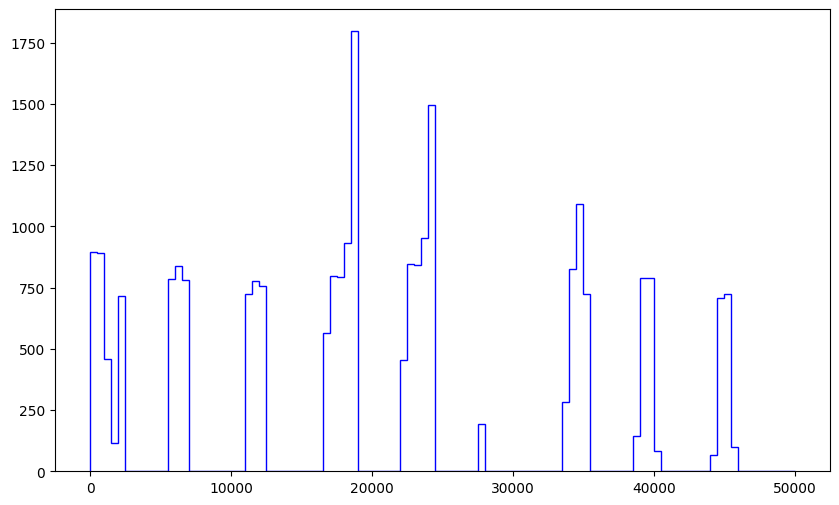

In [12]:
# plot a histogram of the time series
plt.figure(figsize=(10, 6))
hist = plt.hist(ref_time_series, bins=100, range=(0, 50000), histtype='step', color='blue')

In [ ]:
# perform FFT
fft_result = np.fft.fft(binned_time_series)
fft_freq = np.fft.fftfreq(len(binned_time_series), d=bin_size)

In [ ]:
# plot the power spectrum
plt.figure(figsize=(10, 6))
plt.plot(fft_freq[:len(fft_freq)//2], np.abs(fft_result)[:len(fft_result)//2]**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectrum of NICER Observation')